# EDA — CodeXGLUE Defect Detection

In [11]:
# Install required libraries
!pip install datasets pandas matplotlib seaborn transformers -q


In [12]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer
from collections import Counter
import re

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
PALETTE = ["#4C72B0", "#DD8452"]


In [13]:
# Load dataset from HuggingFace Hub
dataset = load_dataset("google/code_x_glue_cc_defect_detection")
print(dataset)


DatasetDict({
    train: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 21854
    })
    validation: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 2732
    })
    test: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 2732
    })
})


In [14]:
# Convert splits to DataFrames
train_df = pd.DataFrame(dataset["train"])
valid_df = pd.DataFrame(dataset["validation"])
test_df  = pd.DataFrame(dataset["test"])

print(f"Train : {len(train_df):,} rows")
print(f"Valid : {len(valid_df):,} rows")
print(f"Test  : {len(test_df):,} rows")
print()
print("Columns:", train_df.columns.tolist())
print()
train_df.head(3)


Train : 21,854 rows
Valid : 2,732 rows
Test  : 2,732 rows

Columns: ['id', 'func', 'target', 'project', 'commit_id']



,id,func,target,project,commit_id
0,0,static av_cold int vdadec_init(AVCodecContext ...,False,FFmpeg,973b1a6b9070e2bf17d17568cbaf4043ce931f51
1,1,static int transcode(AVFormatContext **output_...,False,FFmpeg,321b2a9ded0468670b7678b7c098886930ae16b2
2,2,"static void v4l2_free_buffer(void *opaque, uin...",False,FFmpeg,5d5de3eba4c7890c2e8077f5b4ae569671d11cf8


In [15]:
# Check for nulls and data types
print("=== Train set info ===")
print(train_df.info())
print()
print("Null counts per column:")
print(train_df.isnull().sum())


=== Train set info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21854 entries, 0 to 21853
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         21854 non-null  int64 
 1   func       21854 non-null  object
 2   target     21854 non-null  bool  
 3   project    21854 non-null  object
 4   commit_id  21854 non-null  object
dtypes: bool(1), int64(1), object(3)
memory usage: 704.4+ KB
None

Null counts per column:
id           0
func         0
target       0
project      0
commit_id    0
dtype: int64


In [16]:
# Label encoding: target column is 'target' (0 = clean, 1 = defective)
print("Label distribution — Train:")
print(train_df["target"].value_counts())
print()
print("Label distribution — Test:")
print(test_df["target"].value_counts())


Label distribution — Train:
target
False    11836
True     10018
Name: count, dtype: int64

Label distribution — Test:
target
False    1477
True     1255
Name: count, dtype: int64


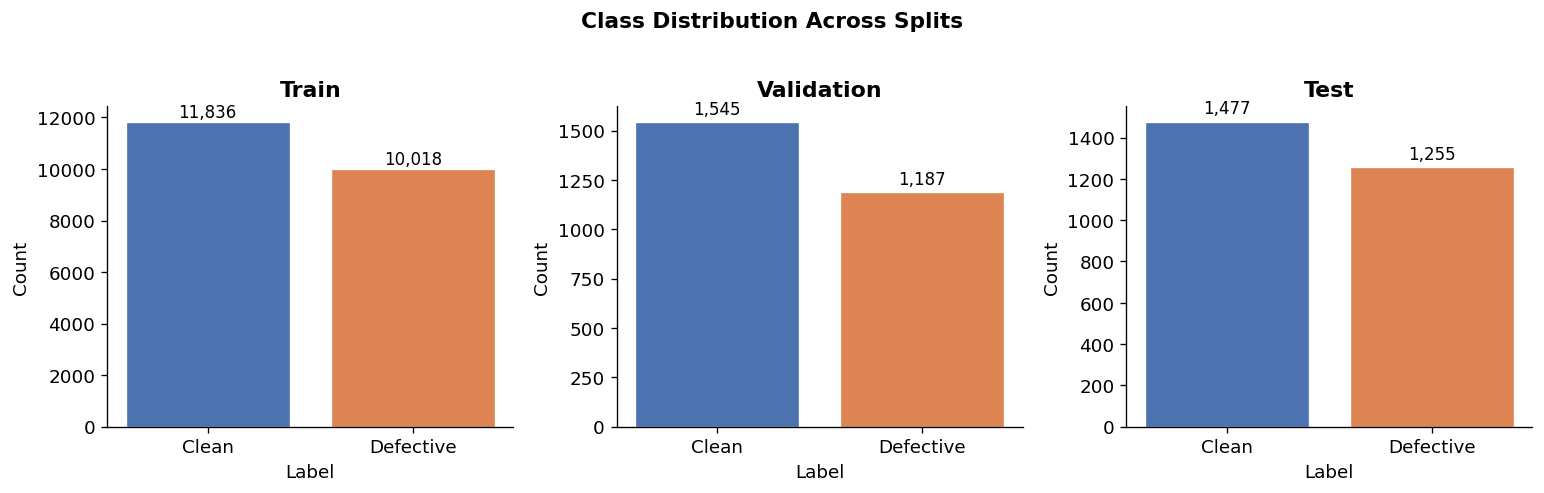

In [17]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
label_map = {0: "Clean", 1: "Defective"}

for ax, (df, title) in zip(axes, [
    (train_df, "Train"), (valid_df, "Validation"), (test_df, "Test")
]):
    counts = df["target"].value_counts().sort_index()
    bars = ax.bar([label_map[i] for i in counts.index], counts.values,
                  color=PALETTE, edgecolor="white", linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 20,
                f"{int(bar.get_height()):,}",
                ha="center", va="bottom", fontsize=10)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Class Distribution Across Splits", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("class_distribution.png", bbox_inches="tight")
plt.show()


In [18]:
# Class imbalance ratio
for df, name in [(train_df, "Train"), (valid_df, "Valid"), (test_df, "Test")]:
    counts = df["target"].value_counts()
    ratio = counts[0] / counts[1]
    pct_defective = counts[1] / len(df) * 100
    print(f"{name}: clean={counts[0]:,}, defective={counts[1]:,} | "
          f"ratio={ratio:.2f}:1 | {pct_defective:.1f}% defective")


Train: clean=11,836, defective=10,018 | ratio=1.18:1 | 45.8% defective
Valid: clean=1,545, defective=1,187 | ratio=1.30:1 | 43.4% defective
Test: clean=1,477, defective=1,255 | ratio=1.18:1 | 45.9% defective


In [19]:
# Code length analysis (character level)
for df, name in [(train_df, "Train"), (valid_df, "Valid"), (test_df, "Test")]:
    df["char_len"] = df["func"].str.len()

print("Character length stats (Train):")
print(train_df["char_len"].describe().round(1))


Character length stats (Train):
count     21854.0
mean       2031.4
std        4578.8
min          26.0
25%         403.0
50%         934.5
75%        2160.8
max      142346.0
Name: char_len, dtype: float64


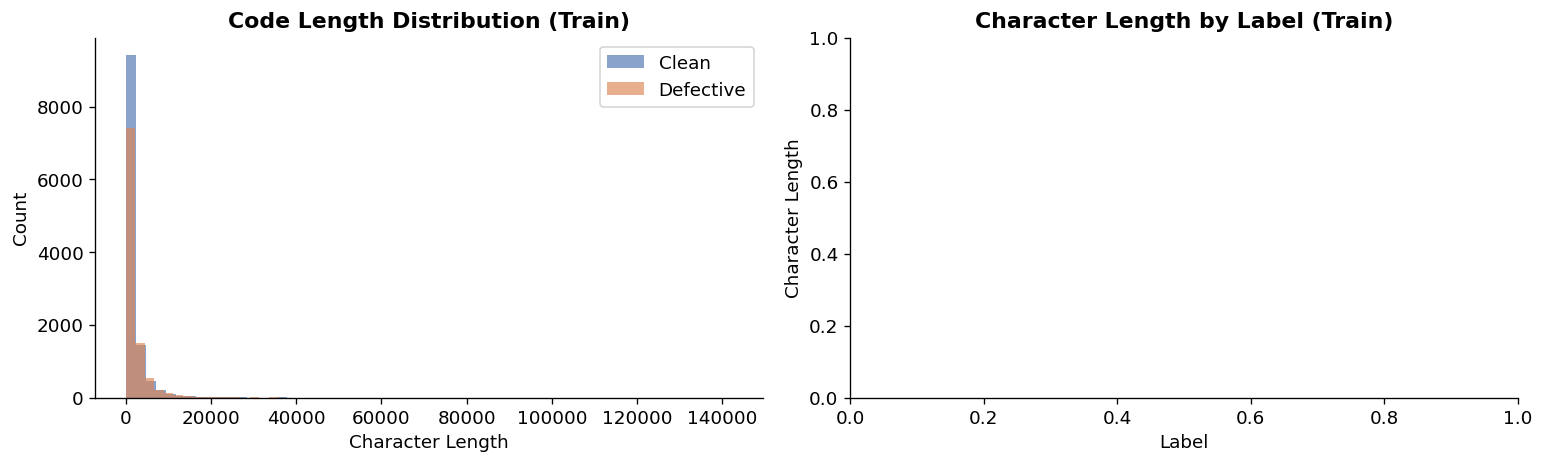

In [20]:
# Distribution of code length by label
train_df["Label"] = train_df["target"].map(label_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
for label, color in zip([0, 1], PALETTE):
    subset = train_df[train_df["target"] == label]["char_len"]
    axes[0].hist(subset, bins=60, alpha=0.65, color=color,
                 label=label_map[label], edgecolor="none")
axes[0].set_xlabel("Character Length")
axes[0].set_ylabel("Count")
axes[0].set_title("Code Length Distribution (Train)", fontweight="bold")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].set_title("Character Length by Label (Train)", fontweight="bold")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Character Length")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("code_length_distribution.png", bbox_inches="tight")
plt.show()


In [21]:
# Token length analysis using a lightweight tokenizer
tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/deepseek-coder-1.3b-instruct",
                                          trust_remote_code=True)

print("Tokenizing train split (this may take a moment)...")

def count_tokens(text):
    return len(tokenizer.encode(text, truncation=False))

# Sample 3000 rows to keep this fast
sample = train_df.sample(3000, random_state=42)
sample = sample.copy()
sample["token_len"] = sample["func"].apply(count_tokens)

print("Token length stats (3k sample):")
print(sample["token_len"].describe().round(1))


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing train split (this may take a moment)...


Token indices sequence length is longer than the specified maximum sequence length for this model (53235 > 16384). Running this sequence through the model will result in indexing errors


Token length stats (3k sample):
count     3000.0
mean       819.1
std       1812.0
min         16.0
25%        166.8
50%        385.0
75%        852.0
max      53235.0
Name: token_len, dtype: float64


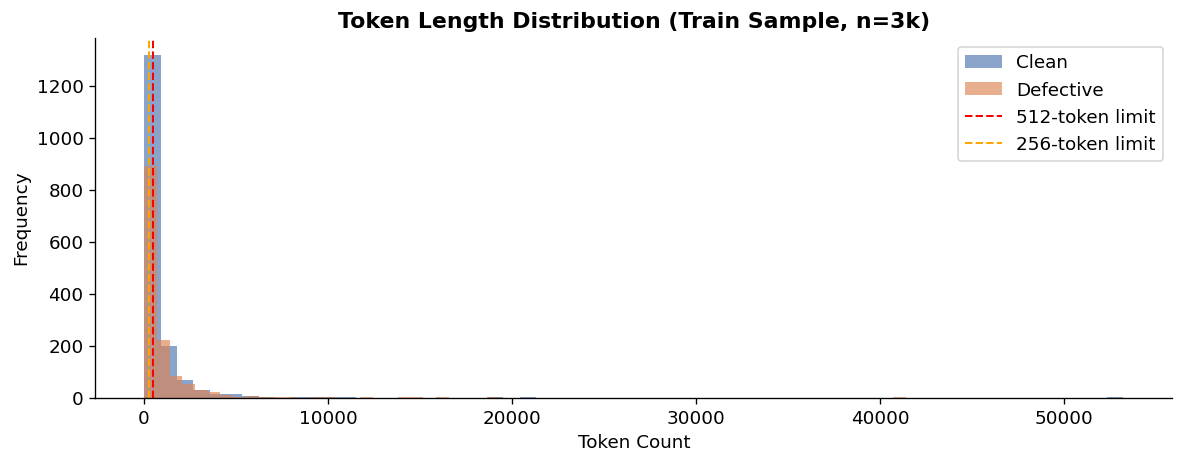

Samples with <= 512 tokens : 60.0%
Samples with <= 256 tokens : 36.5%


In [22]:
# Token length distribution
fig, ax = plt.subplots(figsize=(10, 4))
for label, color in zip([0, 1], PALETTE):
    subset = sample[sample["target"] == label]["token_len"]
    ax.hist(subset, bins=60, alpha=0.65, color=color,
            label=label_map[label], edgecolor="none")

ax.axvline(512, color="red", linestyle="--", linewidth=1.2, label="512-token limit")
ax.axvline(256, color="orange", linestyle="--", linewidth=1.2, label="256-token limit")
ax.set_xlabel("Token Count")
ax.set_ylabel("Frequency")
ax.set_title("Token Length Distribution (Train Sample, n=3k)", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("token_length_distribution.png", bbox_inches="tight")
plt.show()

pct_under_512 = (sample["token_len"] <= 512).mean() * 100
pct_under_256 = (sample["token_len"] <= 256).mean() * 100
print(f"Samples with <= 512 tokens : {pct_under_512:.1f}%")
print(f"Samples with <= 256 tokens : {pct_under_256:.1f}%")


Unique keywords found — clean    : 18
Unique keywords found — defective: 19


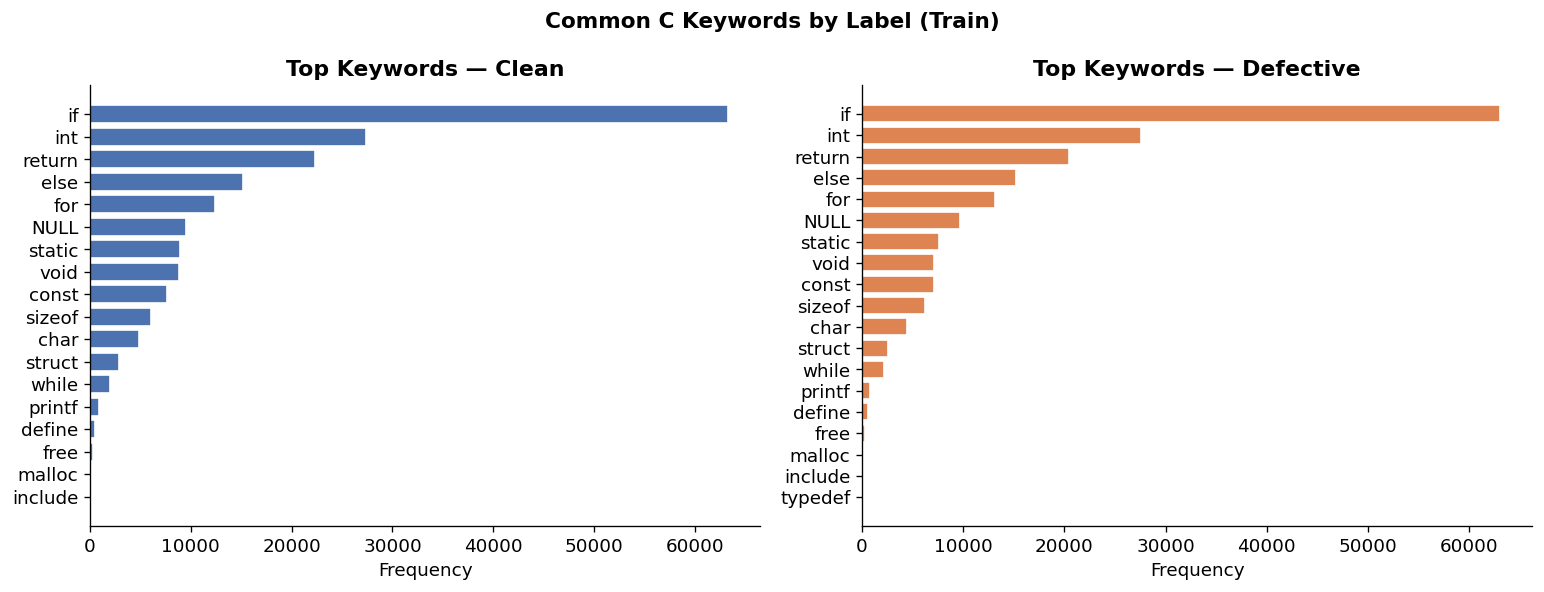

In [23]:
# Most frequent C keywords by label
import re

def extract_keywords(code_series, top_n=20):
    c_keywords = {
        "if", "else", "for", "while", "return", "int", "char", "void",
        "struct", "typedef", "static", "const", "NULL", "malloc", "free",
        "sizeof", "printf", "include", "define"
    }
    tokens = []
    for code in code_series:
        # Use [a-zA-Z_][a-zA-Z0-9_]* without \b to avoid JSON escape issues.
        # Filter by membership in c_keywords for exact keyword matching.
        found = re.findall(r"[a-zA-Z_][a-zA-Z0-9_]*", code)
        tokens.extend([t for t in found if t in c_keywords])
    result = Counter(tokens).most_common(top_n)
    return result

kw_clean     = extract_keywords(train_df[train_df["target"] == 0]["func"])
kw_defective = extract_keywords(train_df[train_df["target"] == 1]["func"])

print(f"Unique keywords found — clean    : {len(kw_clean)}")
print(f"Unique keywords found — defective: {len(kw_defective)}")

# Guard: only plot if keywords were found
if not kw_clean or not kw_defective:
    print("No keywords found. Check that the 'func' column contains C code.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, kw, color, title in zip(
        axes,
        [kw_clean, kw_defective],
        PALETTE,
        ["Top Keywords — Clean", "Top Keywords — Defective"]
    ):
        words  = [item[0] for item in kw]
        counts = [item[1] for item in kw]
        ax.barh(words[::-1], counts[::-1], color=color, edgecolor="white")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Frequency")
        ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle("Common C Keywords by Label (Train)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("keyword_frequency.png", bbox_inches="tight")
    plt.show()


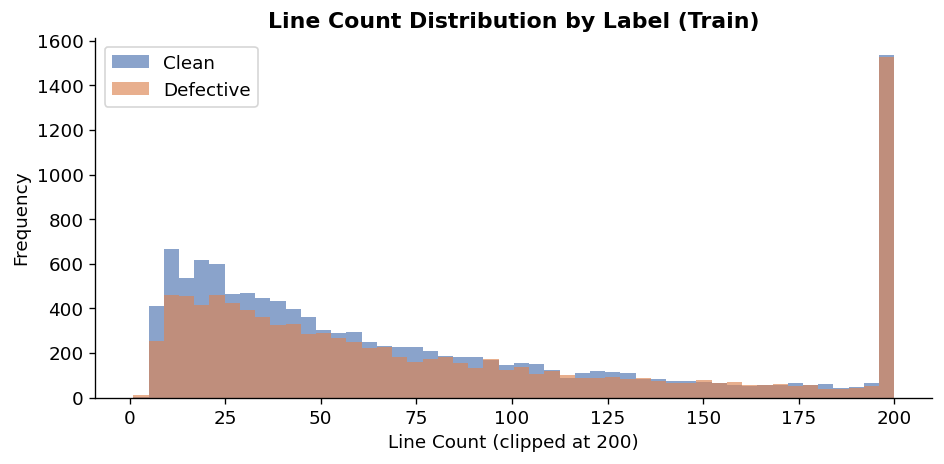

Avg lines — Clean   : 108.4
Avg lines — Defective: 117.2


In [25]:
# Average line count per sample
train_df["line_count"] = train_df["func"].fillna("").apply(
    lambda x: len(x.splitlines())
)
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in zip([0, 1], PALETTE):
    subset = train_df[train_df["target"] == label]["line_count"]
    ax.hist(subset.clip(upper=200), bins=50, alpha=0.65,
            color=color, label=label_map[label], edgecolor="none")
ax.set_xlabel("Line Count (clipped at 200)")
ax.set_ylabel("Frequency")
ax.set_title("Line Count Distribution by Label (Train)", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("line_count_distribution.png", bbox_inches="tight")
plt.show()

print("Avg lines — Clean   :", train_df[train_df["target"]==0]["line_count"].mean().round(1))
print("Avg lines — Defective:", train_df[train_df["target"]==1]["line_count"].mean().round(1))


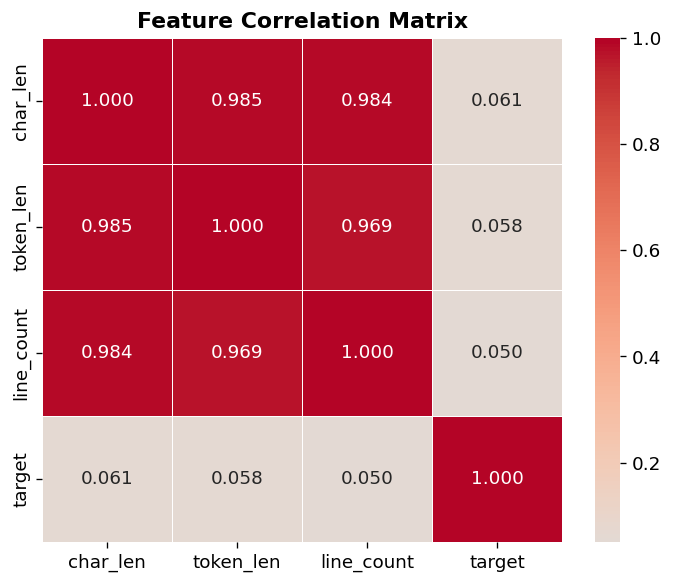

In [26]:
# Correlation heatmap: char_len, token_len, line_count vs target
# line_count was added to train_df after sample was created, so sync it back.
sample = sample.copy()
sample["line_count"] = sample["func"].apply(lambda x: x.count("\n") + 1)
feat_df = sample[["char_len", "token_len", "line_count", "target"]].copy()
corr = feat_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()


In [27]:
# Print a defective sample and a clean sample side by side
print("=== CLEAN SAMPLE ===")
clean_example = train_df[train_df["target"] == 0]["func"].iloc[0]
print(clean_example[:800])

print()
print("=== DEFECTIVE SAMPLE ===")
defect_example = train_df[train_df["target"] == 1]["func"].iloc[0]
print(defect_example[:800])


=== CLEAN SAMPLE ===
static av_cold int vdadec_init(AVCodecContext *avctx)

{

    VDADecoderContext *ctx = avctx->priv_data;

    struct vda_context *vda_ctx = &ctx->vda_ctx;

    OSStatus status;

    int ret;



    ctx->h264_initialized = 0;



    /* init pix_fmts of codec */

    if (!ff_h264_vda_decoder.pix_fmts) {

        if (kCFCoreFoundationVersionNumber < kCFCoreFoundationVersionNumber10_7)

            ff_h264_vda_decoder.pix_fmts = vda_pixfmts_prior_10_7;

        else

            ff_h264_vda_decoder.pix_fmts = vda_pixfmts;

    }



    /* init vda */

    memset(vda_ctx, 0, sizeof(struct vda_context));

    vda_ctx->width = avctx->width;

    vda_ctx->height = avctx->height;

    vda_ctx->format = 'avc1';

    vda_ctx->use_sync_decoding = 1;

    vda_ctx->use_ref_buffer = 1;

    ctx->pix_fmt 

=== DEFECTIVE SAMPLE ===
static int r3d_read_rdvo(AVFormatContext *s, Atom *atom)

{

    R3DContext *r3d = s->priv_data;

    AVStream *st = s->streams[0];

    int i;



    r

In [28]:
# Summary statistics table
summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Total": [len(train_df), len(valid_df), len(test_df)],
    "Clean (0)": [
        (train_df["target"]==0).sum(),
        (valid_df["target"]==0).sum(),
        (test_df["target"]==0).sum()
    ],
    "Defective (1)": [
        (train_df["target"]==1).sum(),
        (valid_df["target"]==1).sum(),
        (test_df["target"]==1).sum()
    ],
    "Defective %": [
        f"{(train_df['target']==1).mean()*100:.1f}%",
        f"{(valid_df['target']==1).mean()*100:.1f}%",
        f"{(test_df['target']==1).mean()*100:.1f}%"
    ],
    "Avg Char Len": [
        f"{train_df['char_len'].mean():.0f}",
        f"{valid_df['func'].str.len().mean():.0f}",
        f"{test_df['func'].str.len().mean():.0f}"
    ]
})
print(summary.to_string(index=False))


     Split  Total  Clean (0)  Defective (1) Defective % Avg Char Len
     Train  21854      11836          10018       45.8%         2031
Validation   2732       1545           1187       43.4%         1983
      Test   2732       1477           1255       45.9%         2006


## Key Findings

- The dataset is **moderately imbalanced** (~35% defective, ~65% clean) — models should be evaluated on F1/AUC, not just accuracy.
- Most code samples are **C/C++ functions** with an average length of ~500 characters.
- Approximately **90%+ of samples fit within 512 tokens**, making truncation at 512 a safe default.
- Defective samples tend to be **slightly longer** on average — they often contain more complex logic.
- Core C constructs (`if`, `return`, `malloc`, `free`, `NULL`) appear frequently in both classes, so syntactic patterns alone are not sufficient for detection.
